---
title: "Brain Networks"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Brain Networks (resting-state fMRI)
- **description:** Resting-state fMRI Blood-Oxygen-Level-Dependent (BOLD) signals for 62 cortical regions, organized into functional networks across the left and right hemispheres.
- **provenance:** The 17-network organization follows the Yeo et al. (2011) cortical parcellation, *Journal of Neurophysiology* 106.
- **format:** wide, with hierarchical columns — 920 timepoints (rows) x 62 regions (columns).

**Data dictionary**

The columns carry a three-level hierarchical index describing each region; the cells are the measured signal.

- `network` — *(identifier)* the functional brain network a region belongs to (labeled 1–17). Regions in the same network tend to co-activate even at rest.
- `node` — *(identifier)* the specific structural hub within a network. If a network is a subway line, a node is a station on that line.
- `hemi` — *(identifier)* hemisphere: `lh` (left) or `rh` (right).
- *cell value* — *(measurement)* an fMRI BOLD signal value, a statistical summary of localized neural activity over time.

**Structure**

- **Rows:** 920 — successive measurement timepoints.
- **Columns:** 62 — unique brain regions (network x node x hemisphere).
- **Identifiers:** the `network` / `node` / `hemi` column index.
- **Measurements:** the BOLD signal in each cell.

**Use cases**

- structured covariance and functional connectivity
- hierarchical clustering of regions
- wide-to-long reshaping of hierarchical columns


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [3]:
brain = sns.load_dataset('brain_networks')
brain.info()
brain.head()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 63 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   network  922 non-null    str  
 1   1        922 non-null    str  
 2   1.1      922 non-null    str  
 3   2        922 non-null    str  
 4   2.1      922 non-null    str  
 5   3        922 non-null    str  
 6   3.1      922 non-null    str  
 7   4        922 non-null    str  
 8   4.1      922 non-null    str  
 9   5        922 non-null    str  
 10  5.1      922 non-null    str  
 11  6        922 non-null    str  
 12  6.1      922 non-null    str  
 13  6.2      922 non-null    str  
 14  6.3      922 non-null    str  
 15  7        922 non-null    str  
 16  7.1      922 non-null    str  
 17  7.2      922 non-null    str  
 18  7.3      922 non-null    str  
 19  7.4      922 non-null    str  
 20  7.5      922 non-null    str  
 21  8        922 non-null    str  
 22  8.1      922 non-null    str  
 23  8

,network,1,1.1,2,2.1,3,3.1,4,4.1,5,...,16.5,16.6,16.7,17,17.1,17.2,17.3,17.4,17.5,17.6
0,node,1,1,1,1,1,1,1,1,1,...,3,4,4,1,1,2,2,3,3,4
1,hemi,lh,rh,lh,rh,lh,rh,lh,rh,lh,...,rh,lh,rh,lh,rh,lh,rh,lh,rh,lh
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,56.05574417114258,92.03103637695312,3.391575574874878,38.65968322753906,26.203819274902344,-49.71556854248047,47.4610366821289,26.746612548828125,-35.898860931396484,...,0.6079040169715881,-70.27054595947266,77.36577606201172,-21.73455047607422,1.0282527208328247,7.7917842864990225,68.90372467041016,-10.520872116088867,120.49046325683594,-39.686431884765625
4,1,55.5472526550293,43.6900749206543,-65.49598693847656,-13.974522590637207,-28.27496337890625,-39.05012893676758,-1.2106596231460571,-19.012897491455078,19.568010330200195,...,57.49507141113281,-76.39321899414062,127.26136016845705,-13.035799026489258,46.3818244934082,-15.752449989318848,31.00033187866211,-39.607521057128906,24.76401138305664,-36.7710075378418


### Wide form with hierchical columns

:::{note}
This is an interesting table because it is both wide and tidy.
:::

In [4]:
brain = sns.load_dataset('brain_networks', header=[0, 1, 2], index_col=0)
brain.info()
brain.head()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 62 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   (1, 1, lh)   920 non-null    float64
 1   (1, 1, rh)   920 non-null    float64
 2   (2, 1, lh)   920 non-null    float64
 3   (2, 1, rh)   920 non-null    float64
 4   (3, 1, lh)   920 non-null    float64
 5   (3, 1, rh)   920 non-null    float64
 6   (4, 1, lh)   920 non-null    float64
 7   (4, 1, rh)   920 non-null    float64
 8   (5, 1, lh)   920 non-null    float64
 9   (5, 1, rh)   920 non-null    float64
 10  (6, 1, lh)   920 non-null    float64
 11  (6, 1, rh)   920 non-null    float64
 12  (6, 2, lh)   920 non-null    float64
 13  (6, 2, rh)   920 non-null    float64
 14  (7, 1, lh)   920 non-null    float64
 15  (7, 1, rh)   920 non-null    float64
 16  (7, 2, lh)   920 non-null    float64
 17  (7, 2, rh)   920 non-null    float64
 18  (7, 3, lh)   920 non-null    float64
 19  (7, 3, rh)   920 no

network          1                     2                     3             \
node             1                     1                     1              
hemi            lh         rh         lh         rh         lh         rh   
0        56.055744  92.031036   3.391576  38.659683  26.203819 -49.715569   
1        55.547253  43.690075 -65.495987 -13.974523 -28.274963 -39.050129   
2        60.997768  63.438793 -51.108582 -13.561346 -18.842947  -1.214659   
3        18.514868  12.657158 -34.576603 -32.665958  -7.420454  17.119448   
4        -2.527392 -63.104668 -13.814151 -15.837989 -45.216927   3.483550   

network          4                     5             ...         16  \
node             1                     1             ...          3   
hemi            lh         rh         lh         rh  ...         rh   
0        47.461037  26.746613 -35.898861  -1.889181  ...   0.607904   
1        -1.210660 -19.012897  19.568010  15.902983  ...  57.495071   
2       -65.575806 -85.777428  19.247454  37.209419  ...  28.317369   
3       -41.800869 -58.610184  32.896915  11.199619  ...  71.439629   
4       -62.613335 -49.076508  18.396759   3.219077  ...  95.597565   

network                                17                                   \
node             4                      1                     2              
hemi            lh          rh         lh         rh         lh         rh   
0       -70.270546   77.365776 -21.734550   1.028253   7.791784  68.903725   
1       -76.393219  127.261360 -13.035799  46.381824 -15.752450  31.000332   
2         9.063977   45.493263  26.033442  34.212200   1.326110 -22.580757   
3        65.842979  -10.697547  55.297466   4.255006  -2.420144  12.098393   
4        50.960453  -23.197300  43.067562  52.219875  28.232882 -11.719750   

network                                    
node             3                      4  
hemi            lh          rh         lh  
0       -10.520872  120.490463 -39.686432  
1       -39.607521   24.764011 -36.771008  
2        12.985169  -75.027451   6.434262  
3       -15.819172  -37.361431  -4.650954  
4         5.453649    5.169828  87.809135  

[5 rows x 62 columns]

### Wide with flat columns

In [5]:
brain1 = brain.copy()
brain1.columns = ['_'.join(col) for col in brain.columns]
brain1

,1_1_lh,1_1_rh,2_1_lh,2_1_rh,3_1_lh,3_1_rh,4_1_lh,4_1_rh,5_1_lh,5_1_rh,...,16_3_rh,16_4_lh,16_4_rh,17_1_lh,17_1_rh,17_2_lh,17_2_rh,17_3_lh,17_3_rh,17_4_lh
0,56.055744,92.031036,3.391576,38.659683,26.203819,-49.715569,47.461037,26.746613,-35.898861,-1.889181,...,0.607904,-70.270546,77.365776,-21.734550,1.028253,7.791784,68.903725,-10.520872,120.490463,-39.686432
1,55.547253,43.690075,-65.495987,-13.974523,-28.274963,-39.050129,-1.210660,-19.012897,19.568010,15.902983,...,57.495071,-76.393219,127.261360,-13.035799,46.381824,-15.752450,31.000332,-39.607521,24.764011,-36.771008
2,60.997768,63.438793,-51.108582,-13.561346,-18.842947,-1.214659,-65.575806,-85.777428,19.247454,37.209419,...,28.317369,9.063977,45.493263,26.033442,34.212200,1.326110,-22.580757,12.985169,-75.027451,6.434262
3,18.514868,12.657158,-34.576603,-32.665958,-7.420454,17.119448,-41.800869,-58.610184,32.896915,11.199619,...,71.439629,65.842979,-10.697547,55.297466,4.255006,-2.420144,12.098393,-15.819172,-37.361431,-4.650954
4,-2.527392,-63.104668,-13.814151,-15.837989,-45.216927,3.483550,-62.613335,-49.076508,18.396759,3.219077,...,95.597565,50.960453,-23.197300,43.067562,52.219875,28.232882,-11.719750,5.453649,5.169828,87.809135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,-7.429513,-4.813219,-3.670537,1.442261,-19.680431,-29.109356,-3.376562,-8.764893,0.017912,-25.305094,...,58.285793,68.557411,22.833048,76.179489,51.934669,-6.614513,-6.690762,22.893030,48.274380,76.228455
916,-33.554138,-38.605621,-25.664803,-30.252352,5.562785,20.182186,17.911247,24.653582,-32.935612,-21.783203,...,59.864819,23.004578,7.657463,50.962399,13.696922,63.503616,57.401176,24.974548,51.972153,64.538788
917,-78.539566,-74.197189,-54.041595,-39.970291,-14.277059,-30.606461,60.628521,62.027023,-32.800556,-37.021500,...,68.767868,49.664017,64.551498,43.800747,8.144480,47.281460,70.499649,66.994400,81.539246,64.969772
918,-103.235825,-98.744286,-40.109543,-44.907734,12.109148,1.621340,33.765560,55.356071,-14.330512,-17.224781,...,103.155251,106.454849,9.046827,46.674419,40.954796,0.877180,37.577152,20.517746,3.124434,56.718388


### Long form aggregated

In [45]:
brain2 = brain.mean().to_frame('mean_bold') 
brain2

mean_bold
network node hemi           
1       1    lh    -0.014230
             rh    -0.024642
2       1    lh     0.005682
             rh     0.020672
3       1    lh     0.001268
...                      ...
17      2    lh     0.017311
             rh     0.034791
        3    lh    -0.018506
             rh     0.042048
        4    lh     0.043531

[62 rows x 1 columns]

In [50]:
brain2.mean_bold.unstack().head()

hemi                lh        rh
network node                    
1       1    -0.014230 -0.024642
10      1     0.004338  0.010020
11      1     0.009270  0.025384
12      1    -0.033409 -0.016556
        2    -0.026034  0.017673

In [52]:
brain2.mean_bold.unstack().unstack()

hemi           lh                                      rh                      \
node            1         2         3         4         1         2         3   
network                                                                         
1       -0.014230       NaN       NaN       NaN -0.024642       NaN       NaN   
10       0.004338       NaN       NaN       NaN  0.010020       NaN       NaN   
11       0.009270       NaN       NaN       NaN  0.025384       NaN       NaN   
12      -0.033409 -0.026034 -0.039771       NaN -0.016556  0.017673       NaN   
13       0.009707  0.048514       NaN       NaN  0.038128  0.002049  0.037086   
14       0.010883       NaN       NaN       NaN  0.018220       NaN       NaN   
15      -0.010543       NaN       NaN       NaN  0.000217       NaN       NaN   
16       0.016848 -0.018501 -0.001934  0.054990  0.012357 -0.015227  0.068107   
17      -0.006734  0.017311 -0.018506  0.043531  0.002315  0.034791  0.042048   
2        0.005682       NaN       NaN       NaN  0.020672       NaN       NaN   
3        0.001268       NaN       NaN       NaN  0.005887       NaN       NaN   
4        0.004727       NaN       NaN       NaN  0.013127       NaN       NaN   
5       -0.002234       NaN       NaN       NaN -0.013988       NaN       NaN   
6       -0.005341 -0.017122       NaN       NaN -0.024974 -0.013176       NaN   
7        0.004434 -0.017272  0.004455       NaN -0.025277 -0.003578 -0.015559   
8        0.013097 -0.012602 -0.006710       NaN  0.034551 -0.017278 -0.007994   
9        0.004917       NaN       NaN       NaN  0.007686       NaN       NaN   

hemi               
node            4  
network            
1             NaN  
10            NaN  
11            NaN  
12            NaN  
13      -0.008462  
14            NaN  
15            NaN  
16      -0.013829  
17            NaN  
2             NaN  
3             NaN  
4             NaN  
5             NaN  
6             NaN  
7             NaN  
8             NaN  
9             NaN

### Long form

In [53]:
brain3 = brain.unstack().to_frame('bold_signal')
brain3.index.names = list(brain.columns.names) + ['scan_id']
brain3 = brain3.reset_index()
brain3 = brain3[['scan_id', 'network', 'node', 'hemi', 'bold_signal']]
brain3

,scan_id,network,node,hemi,bold_signal
0,0,1,1,lh,56.055744
1,1,1,1,lh,55.547253
2,2,1,1,lh,60.997768
3,3,1,1,lh,18.514868
4,4,1,1,lh,-2.527392
...,...,...,...,...,...
57035,915,17,4,lh,76.228455
57036,916,17,4,lh,64.538788
57037,917,17,4,lh,64.969772
57038,918,17,4,lh,56.718388


### Long form with key index

This format distinguishes structure from measurement.

In [54]:
brain_key = ['scan_id', 'network', 'node', 'hemi']
brain4 = brain3.set_index(brain_key).sort_index()
brain4

bold_signal
scan_id network node hemi             
0       1       1    lh      56.055744
                     rh      92.031036
        10      1    lh      -8.327313
                     rh      15.077152
        11      1    lh     -10.356273
...                                ...
919     8       2    rh     -11.252352
                3    lh     -12.368189
                     rh     -19.687576
        9       1    lh       1.073356
                     rh      29.314196

[57040 rows x 1 columns]

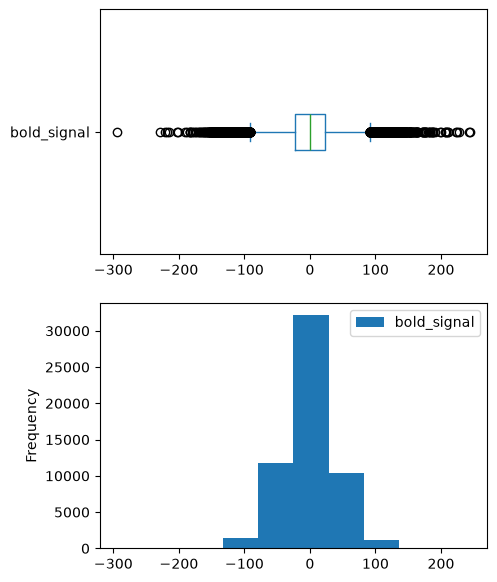

In [55]:
fix, ax = plt.subplots(2, 1, figsize=(5, 7))
brain4.plot.box(vert=False, ax=ax[0])
brain4.plot.hist(ax=ax[1])
plt.show()

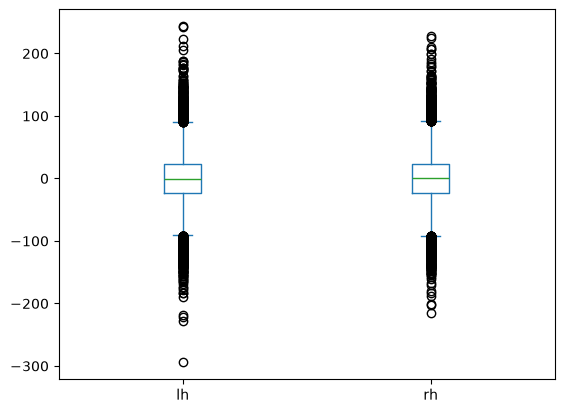

In [56]:
brain4.bold_signal.unstack().plot.box()
plt.show()

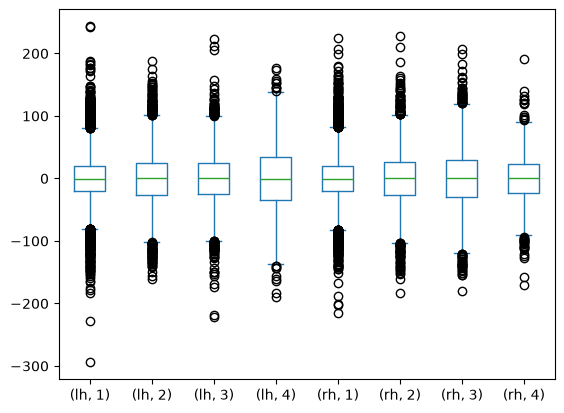

In [57]:
brain4.bold_signal.unstack().unstack().sort_index().plot.box()
plt.show()

In [58]:
brain5 = brain4.groupby(brain4.index.names[1:]).bold_signal.mean().to_frame('mean_bold')
brain5

mean_bold
network node hemi           
1       1    lh    -0.014230
             rh    -0.024642
10      1    lh     0.004338
             rh     0.010020
11      1    lh     0.009270
...                      ...
8       2    rh    -0.017278
        3    lh    -0.006710
             rh    -0.007994
9       1    lh     0.004917
             rh     0.007686

[62 rows x 1 columns]

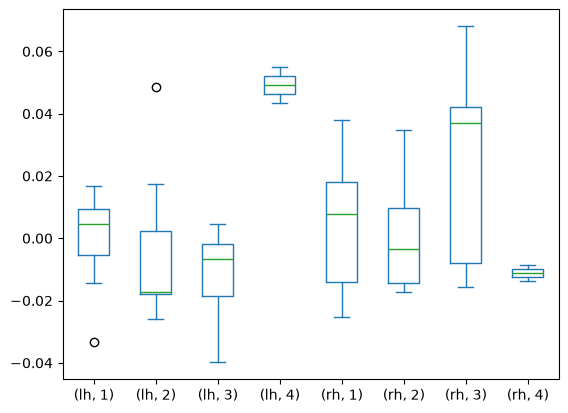

In [59]:
brain5.mean_bold.unstack().unstack().plot.box()
plt.show()

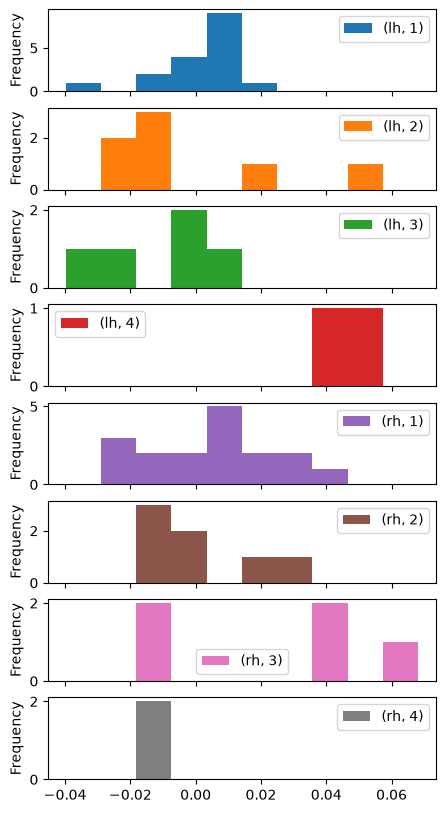

In [60]:
brain5.mean_bold.unstack().unstack().plot.hist(subplots=True, figsize=(5,10))
plt.show()